In [1]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error


In [2]:
df_random = pd.read_csv("complated_clean_data.csv")

In [3]:
df_random.head(5)

,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,0.876693,1.989608,1.008484,0.925295,-0.038259,-1.447797,-1.108065,-0.948655,0.303668,35154898
1,1.238767,1.230524,1.008484,-0.704701,0.619638,-0.330404,0.902474,1.054124,-0.664835,26710893
2,-1.155940,-0.287644,0.106553,-0.355416,-1.354054,2.282091,-1.108065,1.054124,-0.093667,11216242
3,0.109526,0.471440,0.106553,0.284939,0.525653,-0.141549,-1.108065,-0.948655,-0.471135,21984310
4,0.064715,0.471440,1.008484,2.031364,0.995579,-1.825507,-1.108065,1.054124,-0.193000,25080429


In [4]:
x = df_random.drop('house_price_inr',axis=1)
y = df_random['house_price_inr']

In [5]:
from sklearn.model_selection import train_test_split,KFold,cross_val_score

In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
len(x_train)

2871

In [8]:
len(x_test)

718

In [9]:
random_forest = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
)

In [10]:
random_forest.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [11]:
p_test = random_forest.predict(x_test) 

In [12]:
result = pd.DataFrame({
    'accual_values_price' : y_test.values,
    'predicted_house_price' : p_test
})

result

,accual_values_price,predicted_house_price
0,32691574,2.942725e+07
1,25525240,2.647322e+07
2,22740225,1.921653e+07
3,12718440,1.412853e+07
4,20657437,2.271576e+07
...,...,...
713,16954740,1.705871e+07
714,13520657,1.321439e+07
715,19403671,1.832731e+07
716,4225646,5.580383e+06


In [13]:
score = r2_score(y_test,p_test) * 100
print(f"r2 score : {score}")

r2 score : 91.98578580073803


In [14]:
p_train = random_forest.predict(x_train) 

In [15]:
result = pd.DataFrame({
    'accual_values_price' : y_train.values,
    'predicted_house_price' : p_train
})

result

,accual_values_price,predicted_house_price
0,11996712,1.236458e+07
1,17020376,1.478051e+07
2,35531361,3.351768e+07
3,12257583,1.281337e+07
4,15698338,1.653208e+07
...,...,...
2866,26365052,2.724251e+07
2867,28146348,2.821832e+07
2868,34377748,3.419232e+07
2869,18941578,1.935236e+07


In [16]:
score_train = r2_score(y_train,p_train) * 100
print(f"r2 score : {score_train}")

r2 score : 94.68778236222897


In [17]:
mae = mean_absolute_error(y_test,p_test)
print(f"mean absolute error : {mae}")

mean absolute error : 1729913.840606159


In [18]:
mse = mean_squared_error(y_test,p_test)
print(f"mean squared error : {mse}")

mean squared error : 5234084519089.774


In [19]:
kf = KFold(n_splits=5,random_state=42,shuffle=True)

In [20]:
cross_score = cross_val_score(random_forest,x,y,cv=kf,scoring='r2')

In [21]:
print(cross_score)

[0.91962795 0.91366156 0.9273879  0.92504392 0.91821968]


In [22]:
avg_score = cross_score.mean()
print(f"Avrage score : {avg_score}")

Avrage score : 0.9207882034863045


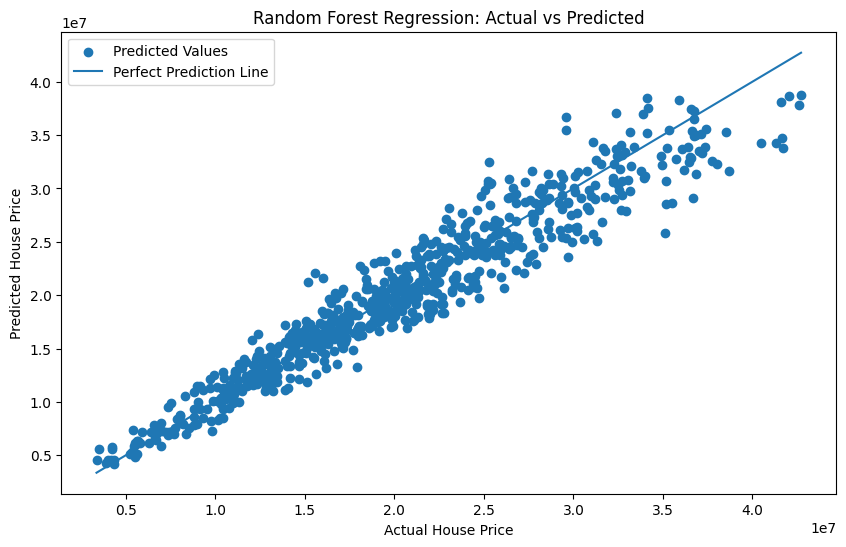

In [23]:
# =====================================
# Random Forest Final Performance Graph
# =====================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    p_test,
    label='Predicted Values'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    label='Perfect Prediction Line'
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Random Forest Regression: Actual vs Predicted")

plt.legend()

plt.show()

# Final Conclusion – Random Forest Regression

| Metric | Value | Interpretation |
|----------|--------|----------------|
| Training R² Score | 94.72% | Model learned training data effectively |
| Testing R² Score | 92.05% | Strong prediction performance on unseen data |
| Average Cross Validation Score | 92.11% | Stable and reliable performance across folds |
| MAE | 1,723,283.63 | Average prediction error |
| MSE | 5,191,255,598,488.81 | Squared prediction error |
| Train-Test Difference | 2.67% | Very small difference indicates very low overfitting |
| Model Performance | Excellent |
| Overfitting Status | Very Low |

## Model Status

✅ Good Model  
❌ Worst Model: No

## Final Business Conclusion

The Random Forest Regression model achieved a training score of **94.72%** and a testing score of **92.05%**. The average cross-validation score of **92.11%** indicates stable and consistent performance across multiple folds. The difference between training and testing scores is only **2.67%**, which shows very low overfitting and strong generalization capability. Therefore, the Random Forest model is considered a reliable and effective model for house price prediction and performs well on unseen data.